In [1]:
import torch 
import torch.nn as nn
import numpy as np 
from datasets import load_dataset
from tqdm import tqdm 
import yaml 
from pathlib import Path

from IPython.display import Audio
import importlib

import torchaudio 

from typing import Dict, List


import sys
sys.path.append('../')
sys.path.append('../lightning_scripts')
sys.path.append('../model_configs')
sys.path.append('../byol-a')

import robustness.audio_functions.audio_transforms as at 

from lightning_scripts.utils.model_build_utils import get_model
from lightning_scripts.byola_lightning_module import BYOLAModule

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    plot_grouped_bars,
)
from pathlib import Path

torch.set_float32_matmul_precision('medium')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

/mnt/ceph/users/igriffith/projects/cochdnn/notebooks/../byol-a/byol_a/common.py:31: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("sox_io")


In [2]:
!nvidia-smi

Mon Feb  9 22:56:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:CA:00.0 Off |                    0 |
| N/A   24C    P0             54W /  225W |    7151MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
torch.cuda.empty_cache()

# Get models

In [4]:
# Device and target sample rate for generated clips
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from lightning_scripts.zero_shot_utils import get_cochdnn9_models, MODEL_SR

layer_out = "relu4"
models, model_name_map = get_cochdnn9_models(layer_out=layer_out, device=DEVICE)


/mnt/ceph/users/igriffith/projects/cochdnn/notebooks/../byol-a/byol_a/models.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = state_dict or torch.load(weigh

# Get the dataset 

In [5]:
speech_commands = load_dataset("google/speech_commands", 'v0.01')

In [6]:
train_split = speech_commands['train']
# remove silence 
train_split = train_split.filter(lambda example: (not ('_silence_' in example['file'])) and (not (example['audio']['array'] is None)))
train_split = train_split.shuffle(seed=1)
val_split = speech_commands['validation']
test_split = speech_commands['test']

In [7]:
class TripletDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset for creating triplets from speech_commands dataset.
    
    Level discrimination task:
    - Each clip contains two words with different levels (a and b, either higher or lower)
    - Anchor: word1_A + word2_A with level relationship (word1 higher/lower than word2)
    - Positive: word1_B + word2_B with same level relationship as anchor (different words)
    - Negative: word1_C + word2_C with reversed level relationship (different words)
    
    All words are different across anchor, positive, and negative.
    """
    
    def __init__(self, dataset_split, seed=None, num_triplets=500, target_sr=20000, sig_length=40000):
        """
        Args:
            dataset_split: HuggingFace dataset split (train/val/test)
            seed: Random seed for reproducibility
            num_triplets: Number of triplets to generate
            target_sr: Target sample rate
            sig_length: Target signal length in samples
        """
        self.dataset_split = dataset_split
        self.target_sr = target_sr
        self.sample_rate = target_sr
        self.sig_length = sig_length
        
        # Get unique labels
        self.label_list = sorted(list(set([ex['label'] for ex in dataset_split])))
        
        # Group examples by label
        self.examples_by_label = {}
        for idx, example in enumerate(dataset_split):
            label = example['label']
            if label not in self.examples_by_label:
                self.examples_by_label[label] = []
            self.examples_by_label[label].append(idx)
        
        # Filter out labels with fewer than 2 examples
        self.valid_labels = {label: indices for label, indices in self.examples_by_label.items() 
                            if len(indices) >= 2}
        
        # Pre-generate triplets for deterministic length
        # Talker selection will be done deterministically in __getitem__ using idx as seed
        if seed is not None:
            np.random.seed(seed)
            torch.manual_seed(seed)
        
        self.triplets = []
        for _ in range(num_triplets):
            # Randomly select two words
            word1, word2 = np.random.choice(self.label_list, size=2, replace=True)
            # Randomly decide which word has higher level (True = word1 higher, False = word2 higher)
            word1_higher = np.random.choice([True, False])
            self.triplets.append((word1, word2, word1_higher))
    
    def __len__(self):
        return len(self.triplets)
    
    def _select_unique_indices(self, word1, word2, rng, num_sets=3):
        """
        Select unique talker indices for anchor, positive, and negative.
        Ensures all indices are unique across all three sets.
        """
        indices1 = self.examples_by_label.get(word1, [])
        indices2 = self.examples_by_label.get(word2, [])
        
        if len(indices1) < num_sets or len(indices2) < num_sets:
            # Fallback: allow reuse if not enough examples
            selected1 = rng.choice(indices1, size=num_sets, replace=True)
            selected2 = rng.choice(indices2, size=num_sets, replace=True)
        else:
            selected1 = rng.choice(indices1, size=num_sets, replace=False)
            selected2 = rng.choice(indices2, size=num_sets, replace=False)
        
        # Ensure we return arrays even for num_sets=1
        if num_sets == 1:
            selected1 = np.array([selected1]) if not isinstance(selected1, np.ndarray) else selected1
            selected2 = np.array([selected2]) if not isinstance(selected2, np.ndarray) else selected2
        return selected1, selected2
    
    def _load_and_normalize_words(self, word, idx, rng):
        """Load and normalize a single word audio."""
        example = self.dataset_split[idx]
        audio = torch.from_numpy(example['audio']['array']).float()
        sr = example['audio']['sampling_rate']
        
        # Resample if needed
        if sr != self.target_sr:
            audio = torchaudio.functional.resample(audio.unsqueeze(0), sr, self.target_sr).squeeze(0)
        
        # RMS normalize
        rms = torch.sqrt(torch.mean(audio ** 2))
        if rms > 1e-6:
            audio = audio / rms
        
        return audio
    
    def _create_word_sequence(self, word1, word2, word1_idx, word2_idx, word1_higher, rng):
        """Create a sequence of two words with level difference."""
        audio1 = self._load_and_normalize_words(word1, word1_idx, rng)
        audio2 = self._load_and_normalize_words(word2, word2_idx, rng)
        
        # Apply level difference: scale one word relative to the other
        level_ratio = 0.20  # Lower word is 20% of higher word's level
        if word1_higher:
            audio2 = audio2 * level_ratio
        else:
            audio1 = audio1 * level_ratio
        
        # Concatenate words
        sequence = torch.cat([audio1, audio2])
        
        # Center crop or pad to target length
        if len(sequence) < self.sig_length:
            pad_dur = (self.sig_length - len(sequence)) // 2 + 1
            sequence = nn.functional.pad(sequence, (pad_dur, pad_dur), "constant", 0)
        
        start_idx = int((len(sequence) - self.sig_length) / 2)
        sequence = sequence[start_idx:start_idx + self.sig_length]
        
        return sequence
    
    def __getitem__(self, idx):
        """
        Returns a tuple: (clips, sr, triplet_info)
        - clips: dict with 'anchor', 'positive', 'negative' keys containing audio tensors
        - sr: sample rate (scalar)
        - triplet_info: dict with metadata about the triplet
        """
        word1, word2, word1_higher = self.triplets[idx]
        rng = np.random.RandomState(idx)
        
        # Select 6 unique words (2 for anchor, 2 for positive, 2 for negative)
        available_words = [w for w in self.label_list if w != word1 and w != word2]
        if len(available_words) < 4:
            available_words = self.label_list
        
        # Anchor words
        word1_A, word2_A = word1, word2
        
        # Positive words (different from anchor words)
        word1_B, word2_B = rng.choice(available_words, size=2, replace=False)
        used_words_AB = {word1_A, word2_A, word1_B, word2_B}
        while word1_B in used_words_AB or word2_B in used_words_AB or word1_B == word2_B:
            word1_B, word2_B = rng.choice(available_words, size=2, replace=False)
        
        # Negative words (different from all previous words)
        remaining_words = [w for w in available_words if w not in used_words_AB]
        if len(remaining_words) < 2:
            remaining_words = [w for w in self.label_list if w not in used_words_AB]
        if len(remaining_words) < 2:
            remaining_words = self.label_list
        
        word1_C, word2_C = rng.choice(remaining_words, size=2, replace=False)
        used_words_ABC = used_words_AB.union({word1_C, word2_C})
        while word1_C in used_words_ABC or word2_C in used_words_ABC or word1_C == word2_C:
            word1_C, word2_C = rng.choice(remaining_words, size=2, replace=False)
        
        # Select unique indices for each word pair
        selected1_A, selected2_A = self._select_unique_indices(word1_A, word2_A, rng, num_sets=1)
        word1_idx_A, word2_idx_A = int(selected1_A[0]), int(selected2_A[0])
        selected1_B, selected2_B = self._select_unique_indices(word1_B, word2_B, rng, num_sets=1)
        word1_idx_B, word2_idx_B = int(selected1_B[0]), int(selected2_B[0])
        selected1_C, selected2_C = self._select_unique_indices(word1_C, word2_C, rng, num_sets=1)
        word1_idx_C, word2_idx_C = int(selected1_C[0]), int(selected2_C[0])
        
        # Create anchor: word1_A + word2_A with level relationship
        anchor = self._create_word_sequence(word1_A, word2_A, word1_idx_A, word2_idx_A, word1_higher, rng)
        
        # Create positive: word1_B + word2_B with same level relationship
        positive = self._create_word_sequence(word1_B, word2_B, word1_idx_B, word2_idx_B, word1_higher, rng)
        
        # Create negative: word1_C + word2_C with reversed level relationship
        # negative = self._create_word_sequence(word1_C, word2_C, word1_idx_C, word2_idx_C, not word1_higher, rng)
        
        # Create negative: same as positive but with opposite level order
        negative = self._create_word_sequence(word1_B, word2_B, word1_idx_B, word2_idx_B, not word1_higher, rng)
        
        clips = {
            "anchor": anchor,
            "positive": positive,
            "negative": negative
        }
        
        triplet_info = {
            "anchor": {
                "word1": word1_A,
                "word2": word2_A,
                "word1_higher": word1_higher
            },
            "positive": {
                "word1": word1_B,
                "word2": word2_B,
                "word1_higher": word1_higher
            },
            "negative": {
                "word1": word1_B,
                "word2": word2_B,
                "word1_higher": not word1_higher
            }
        }
        
        return clips, self.target_sr, triplet_info


# Create dataset
triplet_dataset = TripletDataset(val_split, seed=0, num_triplets=2000)


In [8]:
def speech_commands_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

triplet_loader = torch.utils.data.DataLoader(
    triplet_dataset, batch_size=1, shuffle=False, collate_fn=speech_commands_triplet_collate
)
print(f"Triplet dataset ready: {len(triplet_dataset)} examples at target_sr={triplet_dataset.sample_rate}")

# Test the dataset format
clips, sr, triplet_info = triplet_dataset[0]
print(f"Sample rate: {sr}")
print(f"Clip shapes: anchor={clips['anchor'].shape}, positive={clips['positive'].shape}, negative={clips['negative'].shape}")
print(f"Triplet info: word1={triplet_info['anchor']['word1']}, word2={triplet_info['anchor']['word2']}")
print(f"Level relationship: anchor word1_higher={triplet_info['anchor']['word1_higher']}")
display(Audio(clips['anchor'], rate=sr))
display(Audio(clips['positive'], rate=sr))
display(Audio(clips['negative'], rate=sr))

Triplet dataset ready: 2000 examples at target_sr=20000
Sample rate: 20000
Clip shapes: anchor=torch.Size([40000]), positive=torch.Size([40000]), negative=torch.Size([40000])
Triplet info: word1=12, word2=15
Level relationship: anchor word1_higher=False


## Evaluation

In [9]:
import pandas as pd
from tqdm.auto import tqdm


from lightning_scripts.zero_shot_utils import CenterCropOrPad, distance_metrics_on_triplet, MODEL_SR

crop_or_pad = CenterCropOrPad(40000)
db_spl = 60 
set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(db_spl)



In [10]:
!nvidia-smi

Mon Feb  9 22:57:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:CA:00.0 Off |                    0 |
| N/A   25C    P0             54W /  225W |   14192MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [11]:
# Evaluate models on triplets and collect simple L2 stats
all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(triplet_loader), total=len(triplet_loader), desc="Evaluating triplets"):
    for name, model in models.items():
        sr_val = int(sr)
        word1 = triplet["anchor"]["word1"]
        word2 = triplet["anchor"]["word2"]
        word1_higher = triplet["anchor"]["word1_higher"]
        metrics = distance_metrics_on_triplet(model, clips, sr_val, device=DEVICE, include_cosine=True)
        metrics.update({
            "model": name,
            "batch_idx": batch_idx,
            "word1": word1,
            "word2": word2,
            "word1_higher": word1_higher
        })
        all_results.append(metrics)

results_df = pd.DataFrame(all_results)
results_df['model_name'] = results_df['model'].map(model_name_map)
display(results_df.head())


Evaluating triplets:   0%|          | 0/2000 [00:00<?, ?it/s]

,pos_l2,neg_l2,pos_l2_sq,neg_l2_sq,l2_judgement,sqr_l2_judgement,judgement_pos_lt_neg,pos_cos,neg_cos,cos_judgement,pos_r,neg_r,r_judgement,model,batch_idx,word1,word2,word1_higher,model_name
0,66.532600,71.647263,4426.586916,5133.330234,1,1,1,0.477745,0.273245,1,0.477745,0.273245,1,ssl_λ=0.0,0,12,15,False,CochCNN9 ssl λ=0.0
1,49.318130,57.860512,2432.277995,3347.838823,1,1,1,0.588890,0.313767,1,0.588890,0.313767,1,ssl_λ=0.1,0,12,15,False,CochCNN9 ssl λ=0.1
2,36.225403,40.322495,1312.279810,1625.903563,1,1,1,0.550662,0.334780,1,0.550662,0.334780,1,ssl_λ=0.2,0,12,15,False,CochCNN9 ssl λ=0.2
3,31.986141,40.858196,1023.113229,1669.392202,1,1,1,0.674802,0.365338,1,0.674802,0.365338,1,ssl_λ=0.3,0,12,15,False,CochCNN9 ssl λ=0.3
4,35.052288,48.470074,1228.662898,2349.348044,1,1,1,0.754827,0.459288,1,0.754827,0.459288,1,ssl_λ=0.4,0,12,15,False,CochCNN9 ssl λ=0.4


In [12]:
## write out results to csv
out_dir = Path("../results_dfs")
out_dir.mkdir(exist_ok=True, parents=True)
results_df.to_csv(out_dir / f"zero_shot_speech_commands_level_discrimination_results_{layer_out}_v2.csv", index=False)



In [13]:
results_df.model_name.unique()

array(['CochCNN9 ssl λ=0.0', 'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.2',
       'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.4', 'CochCNN9 ssl λ=0.5',
       'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled ssl λ=0.5',
       'CochCNN9 supervised word', 'CochCNN9 supervised audioset',
       'CochCNN9 supervised multi-task', 'CochCNN9 scaled supervised',
       'CochCNN9 random weights', 'byol-a'], dtype=object)

In [14]:
# reload plotting utils
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    plot_grouped_bars,
)


In [16]:
results_df

,pos_l2,neg_l2,pos_l2_sq,neg_l2_sq,l2_judgement,sqr_l2_judgement,judgement_pos_lt_neg,pos_cos,neg_cos,cos_judgement,pos_r,neg_r,r_judgement,model,batch_idx,word1,word2,word1_higher,model_name
0,66.532600,71.647263,4426.586916,5133.330234,1,1,1,0.477745,0.273245,1,0.477745,0.273245,1,ssl_λ=0.0,0,12,15,False,CochCNN9 ssl λ=0.0
1,49.318130,57.860512,2432.277995,3347.838823,1,1,1,0.588890,0.313767,1,0.588890,0.313767,1,ssl_λ=0.1,0,12,15,False,CochCNN9 ssl λ=0.1
2,36.225403,40.322495,1312.279810,1625.903563,1,1,1,0.550662,0.334780,1,0.550662,0.334780,1,ssl_λ=0.2,0,12,15,False,CochCNN9 ssl λ=0.2
3,31.986141,40.858196,1023.113229,1669.392202,1,1,1,0.674802,0.365338,1,0.674802,0.365338,1,ssl_λ=0.3,0,12,15,False,CochCNN9 ssl λ=0.3
4,35.052288,48.470074,1228.662898,2349.348044,1,1,1,0.754827,0.459288,1,0.754827,0.459288,1,ssl_λ=0.4,0,12,15,False,CochCNN9 ssl λ=0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,417.826233,423.931732,174578.760908,179718.113547,1,1,1,0.445571,0.446913,0,0.445571,0.446913,0,audioset,1999,10,19,True,CochCNN9 supervised audioset
27996,838.108032,913.008484,702425.073683,833584.491649,1,1,1,0.310057,0.254662,1,0.310057,0.254662,1,multitask,1999,10,19,True,CochCNN9 supervised multi-task
27997,114.528725,151.218018,13116.828775,22866.888840,1,1,1,0.251208,0.109908,1,0.251208,0.109908,1,unbal_audioset,1999,10,19,True,CochCNN9 scaled supervised
27998,0.543652,0.580370,0.295557,0.336830,1,1,1,0.856545,0.814562,1,0.856545,0.814562,1,random_init,1999,10,19,True,CochCNN9 random weights


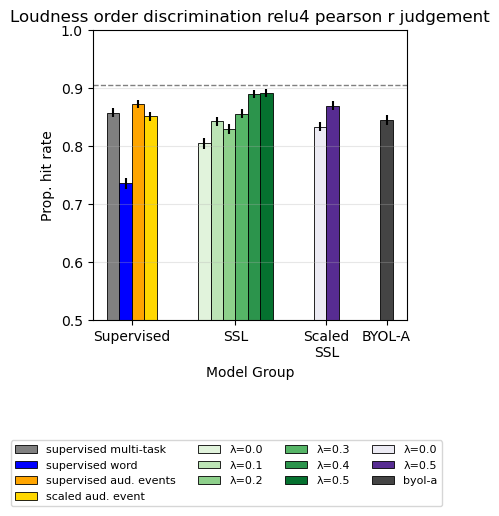

In [17]:
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
hue_order += ["CochCNN9 random weights"]
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)
hue_dict["CochCNN9 random weights"] = "light grey"
# Use plot_grouped_bars for the main squared L2 norm plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

_, legend_handles, legend_labels = plot_grouped_bars(
    ax,
    results_df,
    value_col='r_judgement',
    title=f'Loudness order discrimination {layer_out} pearson r judgement',
    ylabel='Prop. hit rate',
    hue_order=hue_order,
    hue_dict=hue_dict,
    error_type='sem',
    capsize=0,
)

ax.set_ylim(0.5, 1.0)
mean_rand_net = results_df[results_df.model_name.str.contains('rand')].r_judgement.mean()
ax.axhline(mean_rand_net, color='gray', linestyle='--', linewidth=1)
ax.grid(axis='y', alpha=0.3, zorder=-1)

# Add legend
if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=4,
    )

plt.tight_layout()
plt.show()

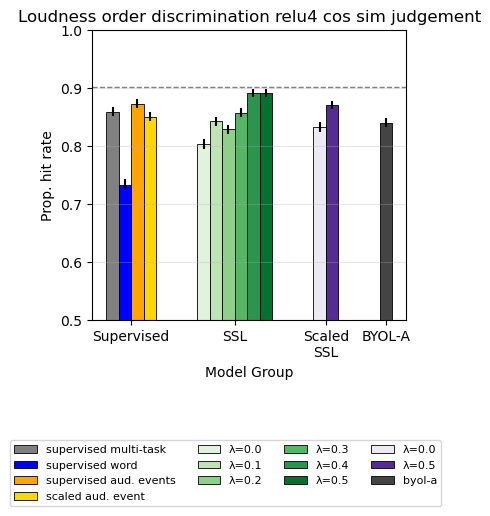

In [15]:
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
hue_order += ["CochCNN9 random weights"]
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)
hue_dict["CochCNN9 random weights"] = "light grey"
# Use plot_grouped_bars for the main squared L2 norm plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

_, legend_handles, legend_labels = plot_grouped_bars(
    ax,
    results_df,
    value_col='cos_judgement',
    title=f'Loudness order discrimination {layer_out} cos sim judgement',
    ylabel='Prop. hit rate',
    hue_order=hue_order,
    hue_dict=hue_dict,
    error_type='sem',
    capsize=0,
)

ax.set_ylim(0.5, 1.0)
mean_rand_net = results_df[results_df.model_name.str.contains('rand')].cos_judgement.mean()
ax.axhline(mean_rand_net, color='gray', linestyle='--', linewidth=1)
ax.grid(axis='y', alpha=0.3, zorder=-1)

# Add legend
if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=4,
    )

plt.tight_layout()
plt.show()

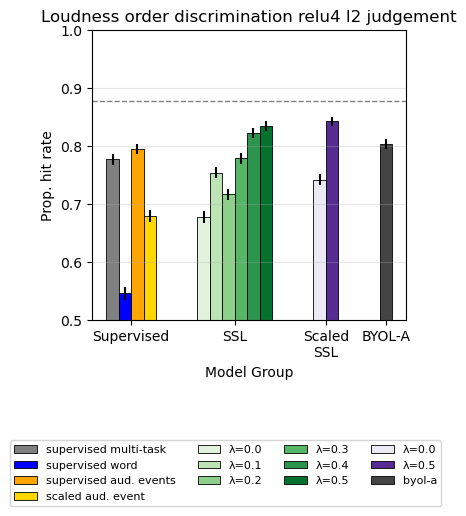

In [20]:
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
hue_order += ["CochCNN9 random weights"]
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)
hue_dict["CochCNN9 random weights"] = "light grey"
# Use plot_grouped_bars for the main squared L2 norm plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

_, legend_handles, legend_labels = plot_grouped_bars(
    ax,
    results_df,
    value_col='sqr_l2_judgement',
    title=f'Loudness order discrimination {layer_out} l2 judgement',
    ylabel='Prop. hit rate',
    hue_order=hue_order,
    hue_dict=hue_dict,
    error_type='sem',
    capsize=0,
)

ax.set_ylim(0.5, 1.0)
mean_rand_net = results_df[results_df.model_name.str.contains("rand")].sqr_l2_judgement.mean()
ax.axhline(mean_rand_net, color='gray', linestyle='--', linewidth=1)
ax.grid(axis='y', alpha=0.3, zorder=-1)

# Add legend
if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=4,
    )

plt.tight_layout()
plt.show()

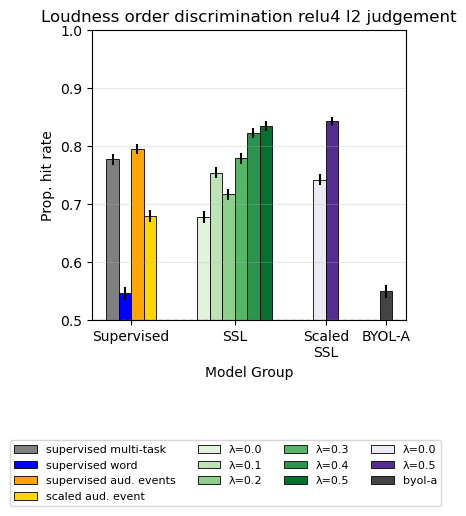

In [27]:
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

# Use plot_grouped_bars for the main squared L2 norm plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

_, legend_handles, legend_labels = plot_grouped_bars(
    ax,
    results_df,
    value_col='sqr_l2_judgement',
    title=f'Loudness order discrimination {layer_out} l2 judgement',
    ylabel='Prop. hit rate',
    hue_order=hue_order,
    hue_dict=hue_dict,
    error_type='sem',
    capsize=0,
)

ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.grid(axis='y', alpha=0.3, zorder=-1)

# Add legend
if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=4,
    )

plt.tight_layout()
plt.show()

In [30]:
results_df.groupby('model').sqr_l2_judgement.mean()

model
audioset            0.7950
byol-a              0.5505
multitask           0.7775
scaled_ssl_λ=0.0    0.7425
scaled_ssl_λ=0.5    0.8430
ssl_λ=0.0           0.6780
ssl_λ=0.1           0.7545
ssl_λ=0.2           0.7170
ssl_λ=0.3           0.7790
ssl_λ=0.4           0.8235
ssl_λ=0.5           0.8355
unbal_audioset      0.6800
word                0.5465
Name: sqr_l2_judgement, dtype: float64

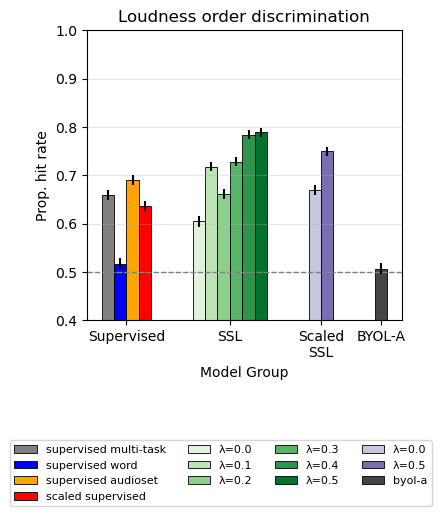

In [ ]:
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

# Use plot_grouped_bars for the main squared L2 norm plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

legend_handles, legend_labels = plot_grouped_bars(
    ax,
    results_df,
    value_col='sqr_l2_judgement',
    title=f'Loudness order discrimination {layer_out}',
    ylabel='Prop. hit rate',
    hue_order=hue_order,
    hue_dict=hue_dict,
    error_type='sem',
    capsize=0,
)

ax.set_ylim(0.4, 1.0)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.grid(axis='y', alpha=0.3, zorder=-1)

# Add legend
if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=4,
    )

plt.tight_layout()
plt.show()

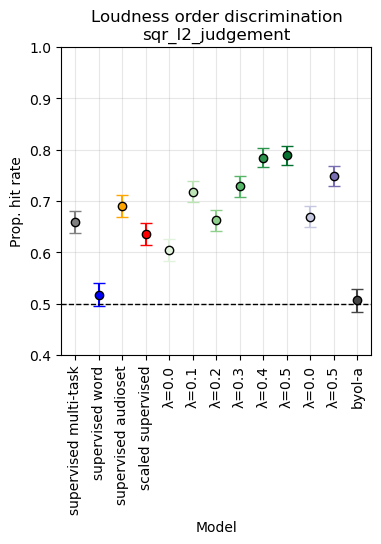

In [ ]:
# For comparison across metrics, use errorbar plots with figure_utils styling
fig, axes = plt.subplots(1, 1, figsize=(4, 4), constrained_layout=False)

# Filter to only models we have data for
available_models = results_df['model_name'].unique()
hue_order_filtered = [m for m in hue_order if m in available_models]

# plot mean judgement for each model
for ix, metric in enumerate(["sqr_l2_judgement"]):
    for model in hue_order_filtered:
        model_data = results_df[results_df.model_name == model][metric]
        if len(model_data) == 0:
            continue
        mean_val = model_data.mean()
        error = 2 * model_data.std() / np.sqrt(len(model_data))
        
        x_pos = hue_order_filtered.index(model)
        color = hue_dict.get(model, '#444444')
        
        axes.errorbar(
            x_pos,
            mean_val,
            fmt='o',
            yerr=error,
            color=color,
            markeredgecolor="k",
            markersize=6,
            capsize=4,
        )
    
    axes.set_title(f"Loudness order discrimination\n{metric}")
    axes.set_ylabel("Prop. hit rate")
    axes.set_xlabel("Model")
    axes.grid(True, alpha=0.3)
    axes.set_ylim(0.4, 1)
    axes.axhline(0.5, color='k', linestyle='--', linewidth=1)
    axes.set_xticks(range(len(hue_order_filtered)))
    axes.set_xticklabels([model_label(m) for m in hue_order_filtered], rotation=90, ha='center')

# plt.tight_layout()


## Load ResNet18 models from eval_dict and supervised models

In [ ]:
import pickle

# Load ResNet18 SSL models from eval_dict
eval_dict_path = Path("train_config_manifests/resnet18_barlow_equivariant_lmbda_search_eval_dict.pkl")
eval_dict = pickle.load(open(eval_dict_path, 'rb'))

# ResNet18 supervised models
resnet18_word_config = Path("model_configs/supervised_models/word_resnet18_MatchedDataset_LARS.yaml")
resnet18_audioset_config = Path("model_configs/supervised_models/audioset_resnet18_MatchedDataset_LARS.yaml")
resnet18_multitask_config = Path("model_configs/supervised_models/word_speaker_audioset_resnet18_MatchedDataset_shuffle_one_gpu_LARS.yaml")

# Load ResNet18 SSL models from eval_dict
resnet18_models = {}
resnet18_model_name_map = {}

for idx, config_path in eval_dict.items():
    config_path = Path(config_path)
    # Extract lambda value from config name for naming
    config_name = config_path.stem
    if 'eq_lmbda' in config_name:
        # Extract lambda value (format: eq_lmbda_5e-01 means 0.5)
        import re
        match = re.search(r'eq_lmbda_(\d+)e-(\d+)', config_name)
        if match:
            coeff = float(match.group(1))
            exp = float(match.group(2))
            lambda_val = coeff * (10 ** -exp)
            model_key = f"resnet18_ssl_λ={lambda_val}"
            resnet18_models[model_key] = get_model(config_path, layer_out="layer4")
            resnet18_model_name_map[model_key] = f"ResNet18 ssl λ={lambda_val}"
        else:
            # Fallback naming
            model_key = f"resnet18_ssl_{idx}"
            resnet18_models[model_key] = get_model(config_path, layer_out="layer4")
            resnet18_model_name_map[model_key] = f"ResNet18 ssl {config_name}"
    elif 'invariant_only' in config_name:
        model_key = "resnet18_ssl_invar"
        resnet18_models[model_key] = get_model(config_path, layer_out="layer4")
        resnet18_model_name_map[model_key] = "ResNet18 ssl invar"

# Load ResNet18 supervised models
resnet18_models["resnet18_word"] = get_model(resnet18_word_config, supervised=True, layer_out="layer4")
resnet18_model_name_map["resnet18_word"] = "ResNet18 supervised word"

resnet18_models["resnet18_audioset"] = get_model(resnet18_audioset_config, supervised=True, layer_out="layer4")
resnet18_model_name_map["resnet18_audioset"] = "ResNet18 supervised audioset"

resnet18_models["resnet18_multitask"] = get_model(resnet18_multitask_config, supervised=True, layer_out="layer4")
resnet18_model_name_map["resnet18_multitask"] = "ResNet18 supervised multi-task"

# Push all ResNet18 models to device
for model in resnet18_models.values():
    model.to(DEVICE)

print(f"Loaded {len(resnet18_models)} ResNet18 models")

## Evaluate ResNet18 models

In [ ]:
# Evaluate ResNet18 models on triplets
resnet18_all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(triplet_loader), total=len(triplet_loader), desc="Evaluating ResNet18 triplets"):
    for name, model in resnet18_models.items():
        sr_val = int(sr)
        word1 = triplet["anchor"]["word1"]
        word2 = triplet["anchor"]["word2"]
        word1_higher = triplet["anchor"]["word1_higher"]
        metrics = distance_metrics_on_triplet(model, clips, sr_val)
        metrics.update({
            "model": name,
            "batch_idx": batch_idx,
            "word1": word1,
            "word2": word2,
            "word1_higher": word1_higher
        })
        resnet18_all_results.append(metrics)

resnet18_results_df = pd.DataFrame(resnet18_all_results)
resnet18_results_df['model_name'] = resnet18_results_df['model'].map(resnet18_model_name_map)
display(resnet18_results_df.head())

## Plot ResNet18 results

In [ ]:
# Plot ResNet18 results
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    plot_grouped_bars,
)

# Get standardized hue order and colors
hue_order = get_standard_hue_order()
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

# Normalize ResNet18 model names
resnet18_results_df['model_name_normalized'] = resnet18_results_df['model_name'].apply(normalize_model_name)

# Filter to models in hue_order if needed
plot_df = resnet18_results_df[resnet18_results_df['model_name_normalized'].isin(hue_order)].copy() if len(resnet18_results_df) > 0 else resnet18_results_df

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

legend_handles, legend_labels = plot_grouped_bars(
    ax,
    plot_df,
    value_col='sqr_l2_judgement',
    title='Loudness order discrimination (ResNet18)',
    ylabel='Prop. hit rate',
    hue_order=hue_order,
    hue_dict=hue_dict,
    error_type='sem',
    capsize=0,
)

ax.set_ylim(0.4, 1.0)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.grid(axis='y', alpha=0.3, zorder=-1)

# Add legend
if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=4,
    )

plt.tight_layout()
plt.show()

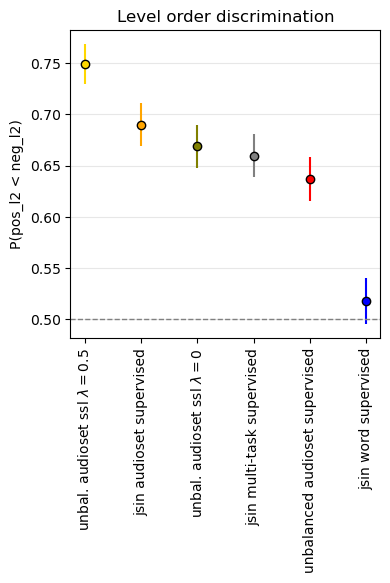

In [44]:
import matplotlib.pyplot as plt

judgement_rate = results_df.groupby("model")["judgement_pos_lt_neg"].mean()
# sort by judgement rate
judgement_rate = judgement_rate.sort_values( ascending=False)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
models_order = judgement_rate.index

for i, model in enumerate(models_order):

    mean_loss = results_df[results_df.model == model]["judgement_pos_lt_neg"].mean()
    error = 2 * results_df[results_df.model == model]["judgement_pos_lt_neg"].std() / np.sqrt(len(results_df[results_df.model == model]))
    axes.errorbar(
        [i],
        [mean_loss],
        fmt='o',
        yerr=error,
        label=model,
        color=palette[model],
        markeredgecolor="k",
    )

xtick_labels = [model_name_dict[model] for model in models_order]

axes.set_xticks(range(len(xtick_labels)))
axes.set_xticklabels(xtick_labels, rotation=90, ha='center')
# axes.set_yticks(np.linspace(0, 1, 5))
# axes.set_ylim(0.5, 1)
axes.axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes.set_ylabel("P(pos_l2 < neg_l2)")
axes.set_title("Level order discrimination")
axes.grid(True, axis="y", alpha=0.3)
plt.show()